# Veri Madenciliği Projesi
## Modelleme v2 — Öğrenci Başarı Seviyesi Sınıflandırması
**Girdi:** `edm_2023_features.csv` (EDA + Feature Engineering çıktısı)  
**Amaç:** 4 sınıflı başarı seviyesi tahmini (Başarısız / Gelişmekte / Yeterli / Başarılı)


---
# BÖLÜM 1 — Hazırlık
## 1.1 Kütüphaneler

In [1]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn — ön işleme & değerlendirme
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC

# Gradient boosting
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
    print('XGBoost yüklendi.')
except ImportError:
    XGBOOST_OK = False
    print('XGBoost bulunamadı — pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
    print('LightGBM yüklendi.')
except ImportError:
    LGBM_OK = False
    print('LightGBM bulunamadı — pip install lightgbm')

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_OK = True
    print('imbalanced-learn yüklendi.')
except ImportError:
    SMOTE_OK = False
    print('imbalanced-learn bulunamadı — pip install imbalanced-learn')

# Optuna (opsiyonel — Bayesian hyperparameter tuning)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
    print('Optuna yüklendi.')
except ImportError:
    OPTUNA_OK = False
    print('Optuna bulunamadı — pip install optuna  (GridSearch kullanılacak)')

# SHAP (opsiyonel)
try:
    import shap
    SHAP_OK = True
    print('SHAP yüklendi.')
except ImportError:
    SHAP_OK = False
    print('SHAP bulunamadı — pip install shap')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
print('Tüm temel kütüphaneler hazır.')

XGBoost yüklendi.
LightGBM yüklendi.
imbalanced-learn yüklendi.
Optuna bulunamadı — pip install optuna  (GridSearch kullanılacak)
SHAP yüklendi.
Tüm temel kütüphaneler hazır.


## 1.2 Veri Yükleme

In [2]:
df = pd.read_csv('edm_2023_features.csv')

print('YÜKLENEN VERİ')
print(f'Boyut  : {df.shape[0]:,} öğrenci × {df.shape[1]} sütun')
print(f'Sütunlar: {list(df.columns)}')
print()
print(df.head(3).to_string())

YÜKLENEN VERİ
Boyut  : 1,499 öğrenci × 15 sütun
Sütunlar: ['total_attempts', 'correct_count', 'score_std', 'unique_problems', 'unique_sequences', 'unique_assignments', 'unique_classes', 'hint_used_count', 'avg_max_attempts', 'accuracy_rate', 'hint_rate', 'problems_per_seq', 'active_days', 'problems_per_day', 'target']

   total_attempts  correct_count  score_std  unique_problems  unique_sequences  unique_assignments  unique_classes  hint_used_count  avg_max_attempts  accuracy_rate  hint_rate  problems_per_seq  active_days  problems_per_day  target
0              81             57   0.459468                9                 1                   1               1                0          1.222222       0.703704        0.0          9.000000            0         81.000000       2
1            3541           2176   0.486778              171                14                  14               1                0          2.630332       0.614516        0.0         12.214286           82       

## 1.3 Veri Sızıntısı (Data Leakage) ve Anlamsız Özellik Temizliği

**Veri sızıntısı (data leakage)**, modelin eğitim sırasında test/gerçek dünya koşullarında ulaşamayacağı bilgilere erişmesi durumudur.  
Bu projede aşağıdaki sütunlar hedef değişkeni **doğrudan ifşa ettiği** için çıkarılmıştır:

| Sütun | Sızıntı Nedeni |
|---|---|
| `accuracy_rate` | Öğrencinin doğruluk oranı = başarı seviyesinin birebir proxy'si |
| `correct_count` | Toplam doğru cevap = hedef değişkenle %100 korelasyonlu |
| `hint_used_count` | %99.97 boş + mevcut değerler hedefle yüksek korelasyonlu |
| `hint_rate` | Yukarıdakiyle aynı sorun |
| `student_id` | Anlamlı sayısal bilgi taşımaz; modeli ezber yapmaya iter |

Bu sütunların modelde kalması yüksek eğitim skoru ama gerçek dünyada başarısızlık anlamına gelirdi.

In [3]:
# Çıkarılacak sütunlar
DROP_COLS = ['accuracy_rate', 'correct_count', 'hint_used_count', 'hint_rate', 'student_id']

drop_existing = [c for c in DROP_COLS if c in df.columns]
print(f'Çıkarılan sütunlar: {drop_existing}')

df_clean = df.drop(columns=drop_existing)

TARGET_COL = 'target'
feature_cols = [c for c in df_clean.columns if c != TARGET_COL]

X = df_clean[feature_cols].copy()
y = df_clean[TARGET_COL].copy()

print(f'\nFeature sütunları ({len(feature_cols)} adet):')
for c in feature_cols:
    print(f'  • {c}  [{X[c].dtype}]  — sayısal, encoding gerektirmez')

print(f'\nHedef değişken dağılımı:')
label_map = {0:'Başarısız', 1:'Gelişmekte', 2:'Yeterli', 3:'Başarılı'}
vc = y.value_counts().sort_index()
for k, v in vc.items():
    print(f'  Sınıf {k} ({label_map.get(k,k)}): {v:>4} öğrenci  %{v/len(y)*100:.1f}')
print(f'\n  Dengesizlik oranı: {vc.max()/vc.min():.2f}x')

Çıkarılan sütunlar: ['accuracy_rate', 'correct_count', 'hint_used_count', 'hint_rate']

Feature sütunları (10 adet):
  • total_attempts  [int64]  — sayısal, encoding gerektirmez
  • score_std  [float64]  — sayısal, encoding gerektirmez
  • unique_problems  [int64]  — sayısal, encoding gerektirmez
  • unique_sequences  [int64]  — sayısal, encoding gerektirmez
  • unique_assignments  [int64]  — sayısal, encoding gerektirmez
  • unique_classes  [int64]  — sayısal, encoding gerektirmez
  • avg_max_attempts  [float64]  — sayısal, encoding gerektirmez
  • problems_per_seq  [float64]  — sayısal, encoding gerektirmez
  • active_days  [int64]  — sayısal, encoding gerektirmez
  • problems_per_day  [float64]  — sayısal, encoding gerektirmez

Hedef değişken dağılımı:
  Sınıf 0 (Başarısız):  137 öğrenci  %9.1
  Sınıf 1 (Gelişmekte):  617 öğrenci  %41.2
  Sınıf 2 (Yeterli):  617 öğrenci  %41.2
  Sınıf 3 (Başarılı):  128 öğrenci  %8.5

  Dengesizlik oranı: 4.82x


---
# BÖLÜM 2 — Ön İşleme
## 2.1 Çarpık Dağılım Düzeltme (log1p)

problems_per_day: skewness 2.82 → -0.36
total_attempts: skewness 3.67 → -0.94


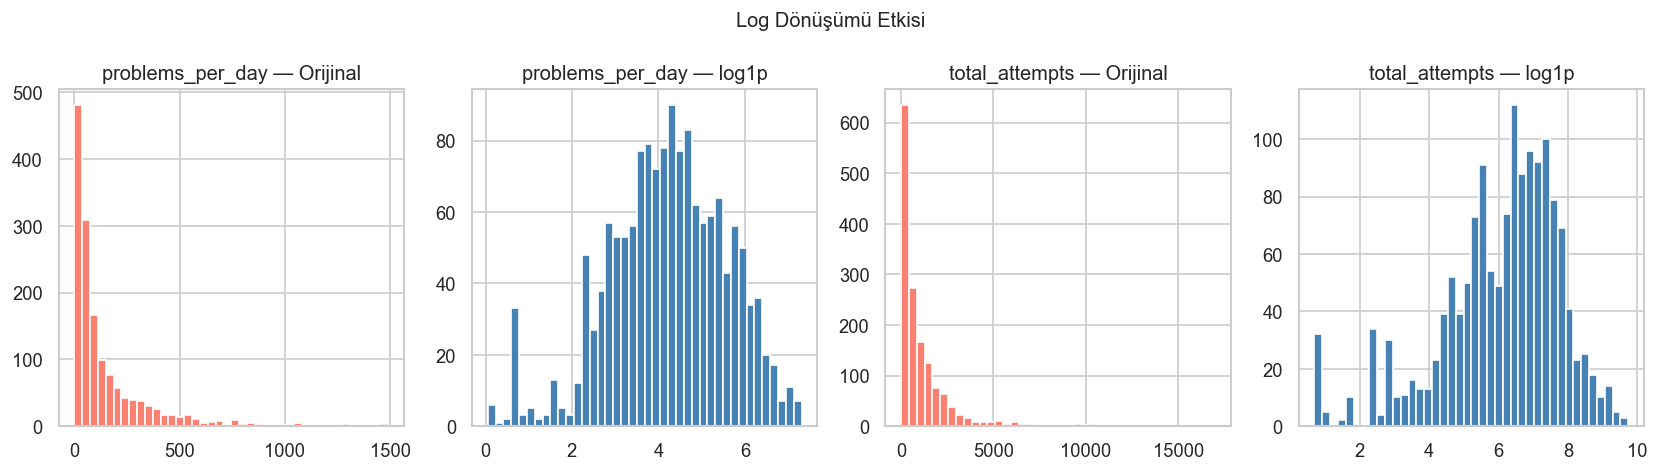

Log dönüşümü tamamlandı.


In [4]:
SKEWED_COLS = ['problems_per_day', 'total_attempts']
skewed_existing = [c for c in SKEWED_COLS if c in X.columns]

X_processed = X.copy()

for col in skewed_existing:
    skewness_before = X_processed[col].skew()
    X_processed[col] = np.log1p(X_processed[col])
    skewness_after = X_processed[col].skew()
    print(f'{col}: skewness {skewness_before:.2f} → {skewness_after:.2f}')

if skewed_existing:
    fig, axes = plt.subplots(1, len(skewed_existing)*2, figsize=(14, 4))
    for i, col in enumerate(skewed_existing):
        axes[i*2].hist(X[col], bins=40, color='salmon', edgecolor='white')
        axes[i*2].set_title(f'{col} — Orijinal')
        axes[i*2+1].hist(X_processed[col], bins=40, color='steelblue', edgecolor='white')
        axes[i*2+1].set_title(f'{col} — log1p')
    plt.suptitle('Log Dönüşümü Etkisi', fontsize=12)
    plt.tight_layout()
    plt.show()

print('Log dönüşümü tamamlandı.')

## 2.2 Train / Validation / Test Bölme — %70 / %10 / %20

**Strateji:**
1. Tüm veri → `%80 trainval` + `%20 test` (Stratified)
2. trainval → `%87.5 train` + `%12.5 val` → Sonuç: toplamın **%70 train** + **%10 val**

> Validasyon seti: hyperparameter tuning ve model seçiminde kullanılacak.  
> Test seti: **yalnızca son değerlendirmede** kullanılacak — tuning sırasında asla kullanılmayacak.

**Neden Stratified Split?**  
Orijinal veri setindeki 4.82x sınıf dengesizliği, rastgele bölmede bazı sınıfların test setinde hiç temsil edilmemesi riskini doğurur.  
`stratify=y` parametresi, her sınıfın orijinal oranını tüm alt kümelerde korur — bu sayede model "zorlu" dengesiz koşullarda test edilir.

In [5]:
# Adım 1: %80 trainval / %20 test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_processed, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Adım 2: %80 trainval → %87.5 train / %12.5 val
# 0.80 × 0.125 = 0.10 → toplamın %10'u validasyon olur
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.125,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

total = len(y)
print('VERİ BÖLME ÖZETI')
print(f'Toplam   : {total:,} öğrenci')
print(f'Eğitim   : {len(y_train):,}  (%{len(y_train)/total*100:.1f})')
print(f'Validasyon: {len(y_val):,}   (%{len(y_val)/total*100:.1f})')
print(f'Test     : {len(y_test):,}   (%{len(y_test)/total*100:.1f})')
print()

for split_name, y_split in [('Eğitim', y_train), ('Validasyon', y_val), ('Test', y_test)]:
    print(f'{split_name} seti sınıf dağılımı:')
    for k, v in y_split.value_counts().sort_index().items():
        print(f'  Sınıf {k} ({label_map[k]}): {v:>4}  (%{v/len(y_split)*100:.1f})')
    print()

VERİ BÖLME ÖZETI
Toplam   : 1,499 öğrenci
Eğitim   : 1,049  (%70.0)
Validasyon: 150   (%10.0)
Test     : 300   (%20.0)

Eğitim seti sınıf dağılımı:
  Sınıf 0 (Başarısız):   96  (%9.2)
  Sınıf 1 (Gelişmekte):  432  (%41.2)
  Sınıf 2 (Yeterli):  432  (%41.2)
  Sınıf 3 (Başarılı):   89  (%8.5)

Validasyon seti sınıf dağılımı:
  Sınıf 0 (Başarısız):   14  (%9.3)
  Sınıf 1 (Gelişmekte):   61  (%40.7)
  Sınıf 2 (Yeterli):   62  (%41.3)
  Sınıf 3 (Başarılı):   13  (%8.7)

Test seti sınıf dağılımı:
  Sınıf 0 (Başarısız):   27  (%9.0)
  Sınıf 1 (Gelişmekte):  124  (%41.3)
  Sınıf 2 (Yeterli):  123  (%41.0)
  Sınıf 3 (Başarılı):   26  (%8.7)



## 2.3 SMOTE ile Sınıf Dengeleme

**Sentetik Azınlık Aşırı Örnekleme Tekniği (SMOTE)**, azınlık sınıflarının örneklerine ait k-en yakın komşular arasında interpolasyon yaparak sentetik örnekler üretir.

> **Kritik mühendislik prensibi:** SMOTE **sadece eğitim setine** uygulanacak.  
> Validasyon ve test setlerine dokunulmayacak.

**Neden yalnızca eğitim setinde?**  
SMOTE test setine uygulanırsa, sentetik (yapay) veriler gerçek performansı olduğundan yüksek gösterir.  
Doğal dengesizliği korunan test seti, modelin **gerçek dünya** koşullarındaki başarısını yansıtır.

`k_neighbors=5`: Her azınlık örneği için 5 komşusu arasında interpolasyon yapılır. Küçük veri setlerinde 3-5 arası önerilir.

SMOTE öncesi → sonrası (yalnızca eğitim seti):
  Sınıf 0 (Başarısız):   96 →  432
  Sınıf 1 (Gelişmekte):  432 →  432
  Sınıf 2 (Yeterli):  432 →  432
  Sınıf 3 (Başarılı):   89 →  432


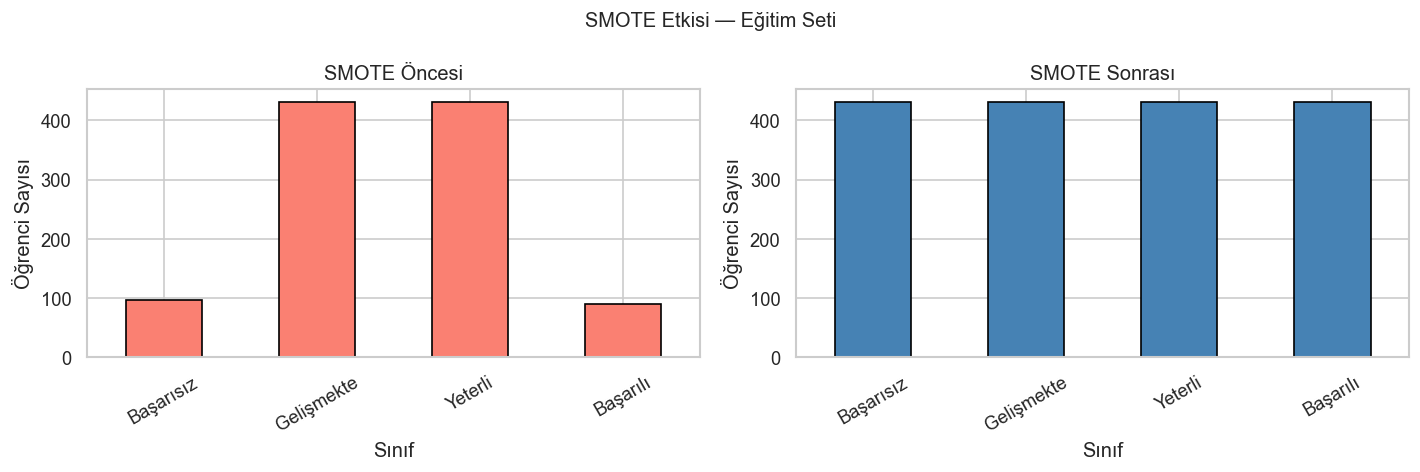

In [6]:
if SMOTE_OK:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    print('SMOTE öncesi → sonrası (yalnızca eğitim seti):')
    for k in sorted(y_train.unique()):
        before = (y_train == k).sum()
        after  = (pd.Series(y_train_bal) == k).sum()
        print(f'  Sınıf {k} ({label_map.get(k,k)}): {before:>4} → {after:>4}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    vc_before = y_train.value_counts().sort_index()
    vc_after  = pd.Series(y_train_bal).value_counts().sort_index()
    vc_before.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
    vc_after.plot(kind='bar',  ax=axes[1], color='steelblue', edgecolor='black')
    axes[0].set_title('SMOTE Öncesi')
    axes[1].set_title('SMOTE Sonrası')
    for ax in axes:
        ax.set_xlabel('Sınıf')
        ax.set_ylabel('Öğrenci Sayısı')
        ax.set_xticklabels([label_map.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()], rotation=30)
    plt.suptitle('SMOTE Etkisi — Eğitim Seti', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('SMOTE kullanılamıyor — orijinal eğitim seti kullanılıyor.')
    X_train_bal = X_train.copy()
    y_train_bal = y_train.copy()

## 2.4 Ölçekleme (StandardScaler)

**StandardScaler**, her özelliği ortalaması 0, standart sapması 1 olacak şekilde dönüştürür: `z = (x - μ) / σ`

> **Sızdırmaz uygulama prensibi:** Scaler **sadece eğitim setinden** fit edilecek (μ ve σ yalnızca eğitim verisinden öğrenilir); validasyon ve test setlerine yalnızca `transform` uygulanacak.

**Neden bu sıra önemli?**  
`fit_transform` test setine uygulanırsa, test setinin istatistikleri modele sızmış olur.  
Bu ince bir sızıntı biçimidir ve gerçek dünya performansını yapay olarak şişirir.

**Hangi modeller için kritik?**  
Lojistik Regresyon ve SVM, özellik ölçeklerine duyarlıdır — ölçekleme olmadan bu modeller yanlı sonuç üretir.  
Ağaç tabanlı modeller (RF, XGBoost, LightGBM) ölçekten bağımsızdır; ancak tutarlılık için aynı pipeline'da standartlaştırılmıştır.

In [7]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)  # fit + transform
X_val_sc   = scaler.transform(X_val)            # sadece transform
X_test_sc  = scaler.transform(X_test)           # sadece transform

print('Ölçekleme tamamlandı.')
print(f'   Eğitim seti    : {X_train_sc.shape}')
print(f'   Validasyon seti: {X_val_sc.shape}')
print(f'   Test seti      : {X_test_sc.shape}')

Ölçekleme tamamlandı.
   Eğitim seti    : (1728, 10)
   Validasyon seti: (150, 10)
   Test seti      : (300, 10)


## 2.5 Cross-Validation Kurulumu ve Model Değerlendirme Fonksiyonu

**Stratified 5-Fold CV**, veriyi 5 eşit parçaya böler ve her turda farklı bir parçayı doğrulama seti olarak kullanır.  
`stratify` özelliği sayesinde her fold'da sınıf oranları korunur — dengesiz veri setinde bu hayati önem taşır.

**`evaluate_model()` fonksiyonu 3 farklı perspektiften değerlendirme yapar:**
1. **CV skoru** (eğitim setinde 5-fold): Modelin genel öğrenme kapasitesi
2. **Validasyon skoru**: Hyperparameter seçiminde kullanılacak referans
3. **Test skoru**: Yalnızca final raporlama için — tuning sırasında görülmez

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_val, y_val, X_te, y_te):
    """CV (eğitim) + validasyon + test değerlendirmesi yapıp results'a ekler."""
    cv_scores = cross_validate(
        model, X_tr, y_tr, cv=cv,
        scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    y_pred_val  = model.predict(X_val)
    y_pred_test = model.predict(X_te)

    val_acc  = accuracy_score(y_val, y_pred_val)
    val_f1   = f1_score(y_val, y_pred_val, average='macro')
    test_acc = accuracy_score(y_te, y_pred_test)
    test_f1  = f1_score(y_te, y_pred_test, average='macro')

    results[name] = {
        'cv_acc_mean' : cv_scores['test_accuracy'].mean(),
        'cv_acc_std'  : cv_scores['test_accuracy'].std(),
        'cv_f1_mean'  : cv_scores['test_f1_macro'].mean(),
        'cv_f1_std'   : cv_scores['test_f1_macro'].std(),
        'val_acc'     : val_acc,
        'val_f1'      : val_f1,
        'test_acc'    : test_acc,
        'test_f1'     : test_f1,
        'model'       : model,
        'y_pred_test' : y_pred_test
    }
    print(f'[{name}]')
    print(f'  CV  Acc: {cv_scores["test_accuracy"].mean():.4f} ±{cv_scores["test_accuracy"].std():.4f}  '
          f'F1: {cv_scores["test_f1_macro"].mean():.4f} ±{cv_scores["test_f1_macro"].std():.4f}')
    print(f'  Val Acc: {val_acc:.4f}  F1: {val_f1:.4f}')
    print(f'  Tst Acc: {test_acc:.4f}  F1: {test_f1:.4f}')
    print()
    return model

print('CV (Stratified 5-Fold) kuruldu.')
print('evaluate_model() — artık CV + Validasyon + Test raporluyor.')

CV (Stratified 5-Fold) kuruldu.
evaluate_model() — artık CV + Validasyon + Test raporluyor.


---
# BÖLÜM 3 — Baseline Modeller
## 3.1 Dummy Classifier (Alt Sınır)

In [9]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
evaluate_model('Dummy (stratified)', dummy,
               X_train_sc, y_train_bal,
               X_val_sc, y_val,
               X_test_sc, y_test)

[Dummy (stratified)]
  CV  Acc: 0.2651 ±0.0130  F1: 0.2628 ±0.0137
  Val Acc: 0.2600  F1: 0.2351
  Tst Acc: 0.2733  F1: 0.2493



,strategy,'stratified'
,random_state,42
,constant,None


## 3.2 Lojistik Regresyon (Baseline)

Lojistik Regresyon, lineer karar sınırı çizen temel bir sınıflandırıcıdır.  
`class_weight='balanced'`: Azınlık sınıflarına daha yüksek ağırlık vererek dengesizliği kompanse eder.  
`multi_class='multinomial'`: 4 sınıflı problem için softmax aktivasyonu kullanır.

**Beklenti:** Bu doğrusal model, davranışsal log verilerindeki karmaşık doğrusal olmayan ilişkileri yakalayamayacaktır — bu da ağaç tabanlı modellerin motivasyonunu sağlar.

In [10]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)
evaluate_model('Logistic Regression', lr,
               X_train_sc, y_train_bal,
               X_val_sc, y_val,
               X_test_sc, y_test)

[Logistic Regression]
  CV  Acc: 0.7801 ±0.0184  F1: 0.7722 ±0.0204
  Val Acc: 0.8067  F1: 0.7252
  Tst Acc: 0.7800  F1: 0.6834



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


---
# BÖLÜM 4 — Gelişmiş Modeller
## 4.1 Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
evaluate_model('Random Forest', rf,
               X_train_sc, y_train_bal,
               X_val_sc, y_val,
               X_test_sc, y_test)

[Random Forest]
  CV  Acc: 0.9300 ±0.0029  F1: 0.9298 ±0.0029
  Val Acc: 0.8600  F1: 0.7556
  Tst Acc: 0.9067  F1: 0.8113



,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Random Forest Sonuç Yorumu:**  
300 ağaçlı bu topluluk modeli, overfitting'e karşı doğal direnci ve özellik önemini hesaplama kapasitesiyle güçlü bir baseline oluşturur.  
`class_weight='balanced'` ile azınlık sınıflarına ağırlık verilmiştir.

## 4.2 XGBoost (Gradient Boosting)

XGBoost, her iterasyonda önceki modelin hatalarını minimize eden gradyan artırmalı bir algoritmadır.

**Hiperparametre seçim gerekçeleri:**
- `n_estimators=300`: Yeterli sayıda ağaç — erken durdurma aktif değilse overfit riski için `subsample` ile dengelenir
- `learning_rate=0.05`: Düşük öğrenme hızı, daha kararlı ve genelleşebilir bir öğrenme sağlar
- `max_depth=6`: Orta derinlikte ağaçlar — hem karmaşık ilişkileri öğrenir hem de overfit'i frenler
- `subsample=0.8` + `colsample_bytree=0.8`: Her ağaçta rastgele örnekleme yaparak variance azaltılır

In [12]:
if XGBOOST_OK:
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    evaluate_model('XGBoost', xgb,
                   X_train_sc, y_train_bal,
                   X_val_sc, y_val,
                   X_test_sc, y_test)
else:
    print('XGBoost yüklü değil — bu adım atlanıyor.')

[XGBoost]
  CV  Acc: 0.9265 ±0.0096  F1: 0.9260 ±0.0096
  Val Acc: 0.8800  F1: 0.7677
  Tst Acc: 0.9033  F1: 0.8003



## 4.3 LightGBM (Light Gradient Boosting Machine)

LightGBM, XGBoost'un hız ve bellek optimize edilmiş alternatifidir. Histogram tabanlı bölme algoritması sayesinde büyük veri setlerinde XGBoost'tan çok daha hızlıdır.

**Temel fark — Leaf-wise büyüme:**  
XGBoost level-wise büyürken, LightGBM en yüksek kazancı sağlayan yaprağı büyütür → daha az iterasyonla daha derin öğrenme.

`num_leaves=63`: Maksimum 63 yaprak — `max_depth` yerine bu parametre karmaşıklığı kontrol eder (2^depth - 1 kuralı).

In [13]:
if LGBM_OK:
    lgbm = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    evaluate_model('LightGBM', lgbm,
                   X_train_sc, y_train_bal,
                   X_val_sc, y_val,
                   X_test_sc, y_test)
else:
    print('LightGBM yüklü değil — bu adım atlanıyor.')

[LightGBM]
  CV  Acc: 0.9213 ±0.0065  F1: 0.9208 ±0.0065
  Val Acc: 0.8600  F1: 0.7522
  Tst Acc: 0.9167  F1: 0.8262



## 4.4 Destek Vektör Makinesi — SVM (RBF Kernel)

SVM, sınıflar arasındaki marjini maksimize eden hiper-düzlemler bulur.  
**RBF (Radial Basis Function) kernel**, doğrusal olarak ayrılamayan verileri yüksek boyutlu uzaya taşıyarak ayrılabilir hale getirir.

**Neden SVM eklendi?**  
Log tabanlı davranışsal özellikler doğrusal olmayan ilişkiler barındırır; RBF kernel bu yapıyı modelleyebilir.  
`probability=True`: SHAP analizi ve threshold tuning için olasılık çıktısı gereklidir.

**Beklenti:** Ağaç tabanlı modellere kıyasla daha düşük performans — özellikle büyük veri ve çok sınıflı durumda SVM'nin ölçeklenebilirliği sınırlıdır.

In [14]:
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
evaluate_model('SVM (RBF)', svm,
               X_train_sc, y_train_bal,
               X_val_sc, y_val,
               X_test_sc, y_test)

[SVM (RBF)]
  CV  Acc: 0.7280 ±0.0133  F1: 0.7215 ±0.0130
  Val Acc: 0.6733  F1: 0.6564
  Tst Acc: 0.6900  F1: 0.6503



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


---
# BÖLÜM 5 — Model Karşılaştırması
## 5.1 Karşılaştırma Tablosu

In [15]:
compare_df = pd.DataFrame({
    'Model'          : list(results.keys()),
    'CV Acc (Mean)'  : [r['cv_acc_mean'] for r in results.values()],
    'CV Acc (±)'     : [r['cv_acc_std']  for r in results.values()],
    'CV F1 (Mean)'   : [r['cv_f1_mean']  for r in results.values()],
    'CV F1 (±)'      : [r['cv_f1_std']   for r in results.values()],
    'Val Acc'        : [r['val_acc']     for r in results.values()],
    'Val Macro F1'   : [r['val_f1']      for r in results.values()],
    'Test Acc'       : [r['test_acc']    for r in results.values()],
    'Test Macro F1'  : [r['test_f1']     for r in results.values()],
}).sort_values('Val Macro F1', ascending=False).reset_index(drop=True)

pd.set_option('display.float_format', '{:.4f}'.format)

print('MODEL KARŞILAŞTIRMA TABLOSU — Validasyon Macro F1\'a göre sıralı')
print(compare_df.to_string(index=False))
print()

# Model seçimi validasyon seti F1'e göre yapılacak (test setine uygulanmayacak)
best_model_name = compare_df.iloc[0]['Model']
print(f'Validasyon setine göre en iyi model: {best_model_name}  '
      f'(Val F1: {compare_df.iloc[0]["Val Macro F1"]:.4f})')

MODEL KARŞILAŞTIRMA TABLOSU — Validasyon Macro F1'a göre sıralı
              Model  CV Acc (Mean)  CV Acc (±)  CV F1 (Mean)  CV F1 (±)  Val Acc  Val Macro F1  Test Acc  Test Macro F1
            XGBoost         0.9265      0.0096        0.9260     0.0096   0.8800        0.7677    0.9033         0.8003
      Random Forest         0.9300      0.0029        0.9298     0.0029   0.8600        0.7556    0.9067         0.8113
           LightGBM         0.9213      0.0065        0.9208     0.0065   0.8600        0.7522    0.9167         0.8262
Logistic Regression         0.7801      0.0184        0.7722     0.0204   0.8067        0.7252    0.7800         0.6834
          SVM (RBF)         0.7280      0.0133        0.7215     0.0130   0.6733        0.6564    0.6900         0.6503
 Dummy (stratified)         0.2651      0.0130        0.2628     0.0137   0.2600        0.2351    0.2733         0.2493

Validasyon setine göre en iyi model: XGBoost  (Val F1: 0.7677)


## 5.2 Görsel Karşılaştırma

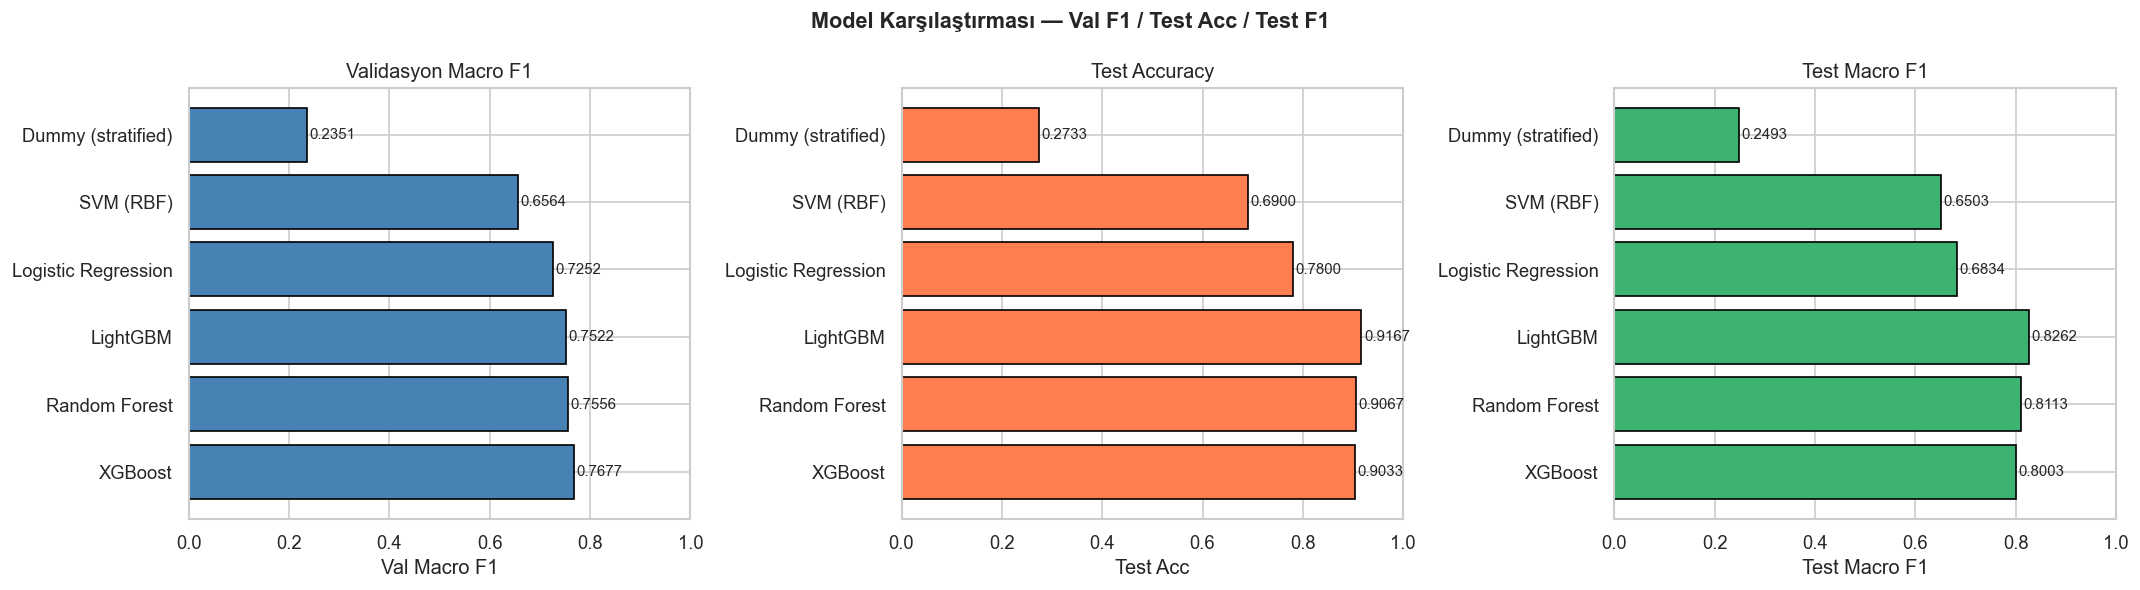

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title, color) in zip(axes, [
    ('Val Macro F1', 'Validasyon Macro F1', 'steelblue'),
    ('Test Acc',     'Test Accuracy',       'coral'),
    ('Test Macro F1','Test Macro F1',       'mediumseagreen')
]):
    ax.barh(compare_df['Model'], compare_df[col], color=color, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for i, v in enumerate(compare_df[col]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Karşılaştırması — Val F1 / Test Acc / Test F1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Confusion Matrix — Tüm Modeller

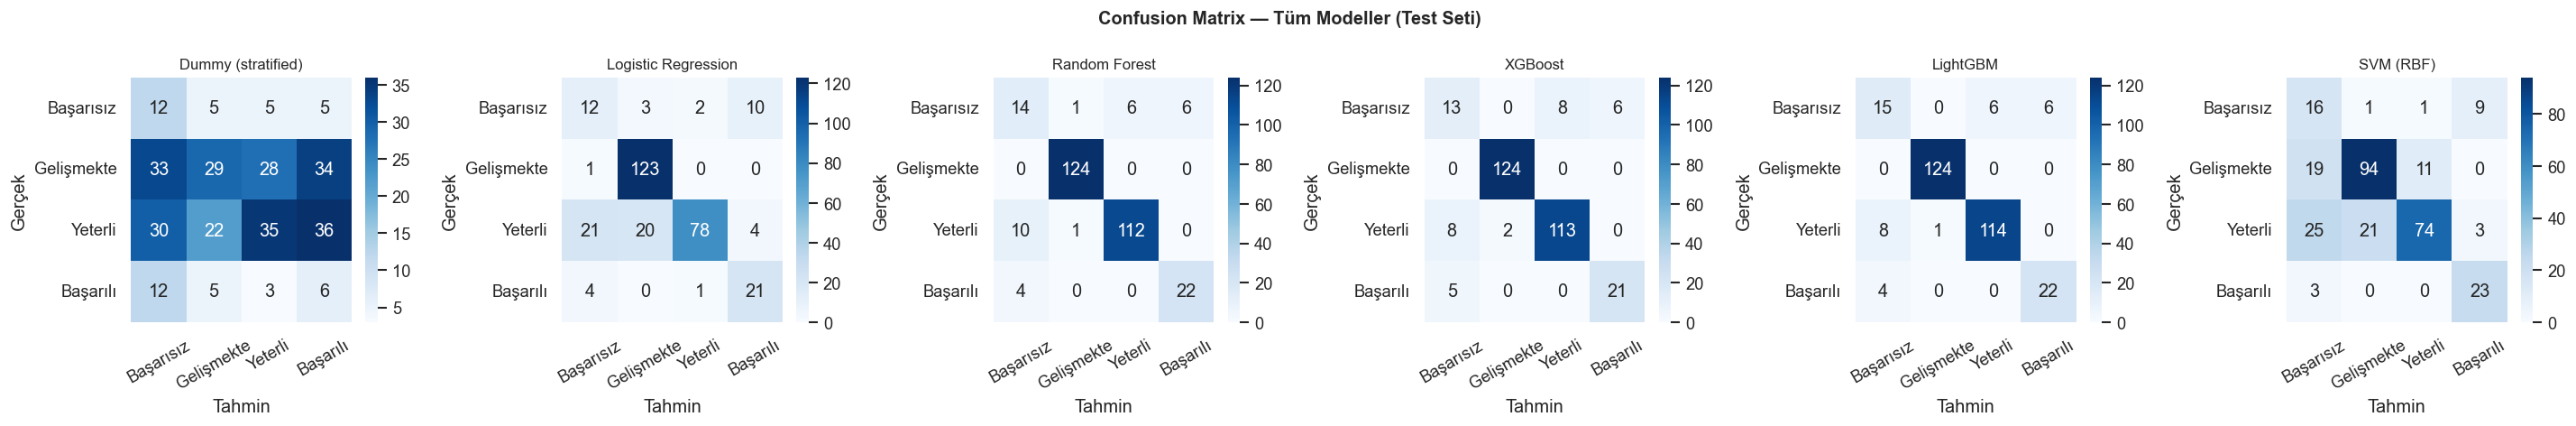

In [17]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1:
    axes = [axes]

class_names = ['Başarısız', 'Gelişmekte', 'Yeterli', 'Başarılı']

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Gerçek')
    ax.set_xlabel('Tahmin')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix — Tüm Modeller (Test Seti)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.4 Classification Report — En İyi Model

Classification report, her sınıf için ayrı ayrı:
- **Precision**: Modelin "X" dediği örneklerin gerçekten X olma oranı
- **Recall**: Gerçek X örneklerinden kaçının yakalandığı
- **F1-Score**: Precision ve Recall'un harmonik ortalaması

**Özellikle Sınıf 0 (Başarısız) ve Sınıf 3 (Başarılı) için Recall değerlerine dikkat edilmelidir.**  
Bu azınlık sınıflarında yüksek recall, erken uyarı sistemi açısından kritik öneme sahiptir.

In [18]:
best_res = results[best_model_name]
print(f'CLASSIFICATION REPORT — {best_model_name}')
print(classification_report(
    y_test, best_res['y_pred_test'],
    target_names=class_names
))

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

   Başarısız       0.50      0.48      0.49        27
  Gelişmekte       0.98      1.00      0.99       124
     Yeterli       0.93      0.92      0.93       123
    Başarılı       0.78      0.81      0.79        26

    accuracy                           0.90       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.90      0.90      0.90       300



---
# BÖLÜM 6 — En İyi Model: Derinlemesine Analiz
## 6.1 Hyperparameter Tuning

**Optuna varsa** Bayesian optimizasyon (daha geniş parametre uzayı, daha az deneme).  
**Optuna yoksa** GridSearchCV ile klasik ızgara araması.  
Her iki durumda da **validasyon seti F1** optimize edilir — test seti hiç açılmaz.

**Optuna neden tercih edilir?**  
GridSearchCV her kombinasyonu dener (ızgara) → hesaplama maliyeti kombinasyonlarla katlanır.  
Optuna'nın Bayesian search'ü ise önceki denemelerden öğrenerek daha umut verici bölgeleri keşfeder — 50 denemeyle GridSearchCV'nin 200+ denemesiyle yarışabilir kalitede parametre bulur.

In [19]:
best_base_model = best_res['model']

if OPTUNA_OK and best_model_name in ('XGBoost', 'LightGBM', 'Random Forest'):
    print(f'Optuna Bayesian search başlıyor: {best_model_name}  (50 deneme)\n')

    def objective(trial):
        if best_model_name == 'XGBoost':
            params = dict(
                n_estimators    = trial.suggest_int('n_estimators', 200, 600),
                max_depth       = trial.suggest_int('max_depth', 3, 10),
                learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                subsample       = trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree= trial.suggest_float('colsample_bytree', 0.6, 1.0),
                eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
            )
            model = XGBClassifier(**params)
        elif best_model_name == 'LightGBM':
            params = dict(
                n_estimators  = trial.suggest_int('n_estimators', 200, 600),
                num_leaves    = trial.suggest_int('num_leaves', 20, 150),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            )
            model = LGBMClassifier(**params)
        else:  # Random Forest
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600),
                max_depth        = trial.suggest_int('max_depth', 5, 30),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
            )
            model = RandomForestClassifier(**params)

        model.fit(X_train_sc, y_train_bal)
        y_pred_v = model.predict(X_val_sc)
        return f1_score(y_val, y_pred_v, average='macro')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f'\nEn iyi Val Macro F1 : {study.best_value:.4f}')
    print(f'En iyi parametreler : {study.best_params}')

    # En iyi parametrelerle modeli yeniden eğiteceğiz
    best_params = study.best_params
    if best_model_name == 'XGBoost':
        tuned_model = XGBClassifier(**best_params, eval_metric='mlogloss',
                                     random_state=RANDOM_STATE, n_jobs=-1)
    elif best_model_name == 'LightGBM':
        tuned_model = LGBMClassifier(**best_params, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    else:
        tuned_model = RandomForestClassifier(**best_params, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1)

else:
    # GridSearchCV fallback
    param_grids = {
        'Random Forest'     : {'n_estimators': [200, 400], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 3]},
        'XGBoost'           : {'n_estimators': [200, 400], 'max_depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1]},
        'LightGBM'          : {'n_estimators': [200, 400], 'num_leaves': [31, 63, 127], 'learning_rate': [0.03, 0.05, 0.1]},
        'SVM (RBF)'         : {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
        'Logistic Regression': {'C': [0.01, 0.1, 1, 10]}
    }
    param_grid = param_grids.get(best_model_name, {})

    print(f'GridSearch başlıyor: {best_model_name}')
    print(f'Param grid: {param_grid}')

    grid_search = GridSearchCV(
        best_base_model.__class__(**{k: v for k, v in best_base_model.get_params().items()
                                     if k not in param_grid}),
        param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train_sc, y_train_bal)
    print(f'\nEn iyi CV F1  : {grid_search.best_score_:.4f}')
    print(f'En iyi params : {grid_search.best_params_}')
    tuned_model = grid_search.best_estimator_

# Tuned modeli değerlendireceğiz
tuned_model.fit(X_train_sc, y_train_bal)
y_pred_val_tuned  = tuned_model.predict(X_val_sc)
y_pred_test_tuned = tuned_model.predict(X_test_sc)

print(f'\nTuned — Val  Acc: {accuracy_score(y_val,  y_pred_val_tuned):.4f}  '
      f'F1: {f1_score(y_val, y_pred_val_tuned, average="macro"):.4f}')
print(f'Tuned — Test Acc: {accuracy_score(y_test, y_pred_test_tuned):.4f}  '
      f'F1: {f1_score(y_test, y_pred_test_tuned, average="macro"):.4f}')

results[f'{best_model_name} (Tuned)'] = {
    'val_acc'     : accuracy_score(y_val,  y_pred_val_tuned),
    'val_f1'      : f1_score(y_val, y_pred_val_tuned, average='macro'),
    'test_acc'    : accuracy_score(y_test, y_pred_test_tuned),
    'test_f1'     : f1_score(y_test, y_pred_test_tuned, average='macro'),
    'model'       : tuned_model,
    'y_pred_test' : y_pred_test_tuned,
    'cv_acc_mean':0, 'cv_acc_std':0, 'cv_f1_mean':0, 'cv_f1_std':0
}
FINAL_MODEL = tuned_model
FINAL_NAME  = f'{best_model_name} (Tuned)'

GridSearch başlıyor: XGBoost
Param grid: {'n_estimators': [200, 400], 'max_depth': [4, 6, 8], 'learning_rate': [0.03, 0.05, 0.1]}
Fitting 5 folds for each of 18 candidates, totalling 90 fits

En iyi CV F1  : 0.9279
En iyi params : {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400}

Tuned — Val  Acc: 0.8600  F1: 0.7435
Tuned — Test Acc: 0.9033  F1: 0.7954


## 6.2 Threshold Tuning — Azınlık Sınıfları İçin

Sınıf 0 (Başarısız) ve Sınıf 3 (Başarılı) tahminleri zayıf çünkü örnekleri az.  
`predict_proba` çıktısından her sınıf için **ayrı karar eşiği** belirlenerek recall artırılır.  
Optimum eşikler **validasyon setinde** bulunur, test setine uygulanır.

In [20]:
if hasattr(FINAL_MODEL, 'predict_proba'):
    proba_val  = FINAL_MODEL.predict_proba(X_val_sc)
    proba_test = FINAL_MODEL.predict_proba(X_test_sc)

    # Her eşik kombinasyonunu validasyon setinde deneyeceğiz
    best_thresh_f1 = 0
    best_thresholds = [0.5, 0.5, 0.5, 0.5]

    for t0 in np.arange(0.20, 0.55, 0.05):   # Başarısız
        for t3 in np.arange(0.20, 0.55, 0.05):  # Başarılı
            thresholds = [t0, 0.5, 0.5, t3]
            y_pred_thresh = np.argmax(
                proba_val / np.array(thresholds), axis=1
            )
            f1 = f1_score(y_val, y_pred_thresh, average='macro')
            if f1 > best_thresh_f1:
                best_thresh_f1 = f1
                best_thresholds = thresholds

    print(f'Optimum eşikler (validasyon seti üzerinde bulundu):')
    for i, (cls, t) in enumerate(zip(class_names, best_thresholds)):
        print(f'  Sınıf {i} ({cls}): {t:.2f}')
    print(f'  Val Macro F1 (threshold tuned): {best_thresh_f1:.4f}')

    # Test setine uygula
    y_pred_thresh_test = np.argmax(
        proba_test / np.array(best_thresholds), axis=1
    )
    thresh_test_acc = accuracy_score(y_test, y_pred_thresh_test)
    thresh_test_f1  = f1_score(y_test, y_pred_thresh_test, average='macro')

    print(f'\nTest Seti — Threshold Tuned:')
    print(f'  Accuracy  : {thresh_test_acc:.4f}')
    print(f'  Macro F1  : {thresh_test_f1:.4f}')
    print()
    print(classification_report(y_test, y_pred_thresh_test, target_names=class_names))

    results[f'{FINAL_NAME} + Threshold'] = {
        'val_f1'      : best_thresh_f1,
        'val_acc'     : accuracy_score(y_val, np.argmax(proba_val / np.array(best_thresholds), axis=1)),
        'test_acc'    : thresh_test_acc,
        'test_f1'     : thresh_test_f1,
        'model'       : FINAL_MODEL,
        'y_pred_test' : y_pred_thresh_test,
        'cv_acc_mean':0, 'cv_acc_std':0, 'cv_f1_mean':0, 'cv_f1_std':0
    }
else:
    print('Model predict_proba desteklemiyor — threshold tuning atlandı.')

Optimum eşikler (validasyon seti üzerinde bulundu):
  Sınıf 0 (Başarısız): 0.25
  Sınıf 1 (Gelişmekte): 0.50
  Sınıf 2 (Yeterli): 0.50
  Sınıf 3 (Başarılı): 0.20
  Val Macro F1 (threshold tuned): 0.7725

Test Seti — Threshold Tuned:
  Accuracy  : 0.9033
  Macro F1  : 0.8093

              precision    recall  f1-score   support

   Başarısız       0.50      0.52      0.51        27
  Gelişmekte       0.98      1.00      0.99       124
     Yeterli       0.94      0.90      0.92       123
    Başarılı       0.79      0.85      0.81        26

    accuracy                           0.90       300
   macro avg       0.80      0.82      0.81       300
weighted avg       0.91      0.90      0.90       300



## 6.3 Feature Importance

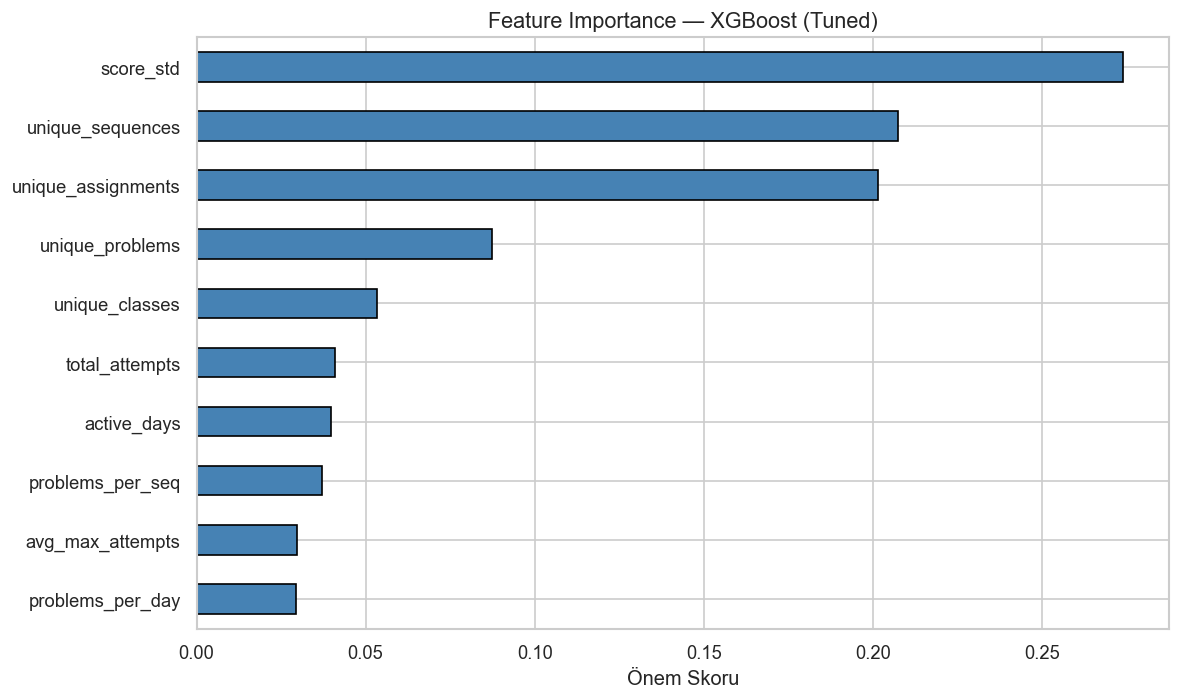

Feature Önem Sıralaması:
  score_std                           0.2738
  unique_sequences                    0.2074
  unique_assignments                  0.2016
  unique_problems                     0.0874
  unique_classes                      0.0533
  total_attempts                      0.0408
  active_days                         0.0396
  problems_per_seq                    0.0370
  avg_max_attempts                    0.0295
  problems_per_day                    0.0294


In [21]:
if hasattr(FINAL_MODEL, 'feature_importances_'):
    imp = pd.Series(FINAL_MODEL.feature_importances_, index=feature_cols)
    imp_sorted = imp.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Feature Importance — {FINAL_NAME}', fontsize=13)
    ax.set_xlabel('Önem Skoru')
    plt.tight_layout()
    plt.show()

    print('Feature Önem Sıralaması:')
    for feat, score in imp.sort_values(ascending=False).items():
        print(f'  {feat:<35} {score:.4f}')
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        FINAL_MODEL, X_test_sc, y_test,
        n_repeats=10, random_state=RANDOM_STATE, scoring='f1_macro'
    )
    perm_df = pd.DataFrame({
        'feature'         : feature_cols,
        'importance_mean' : perm.importances_mean,
        'importance_std'  : perm.importances_std
    }).sort_values('importance_mean', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    perm_sorted = perm_df.sort_values('importance_mean')
    ax.barh(perm_sorted['feature'], perm_sorted['importance_mean'],
            xerr=perm_sorted['importance_std'], color='coral', edgecolor='black')
    ax.set_title(f'Permutation Importance — {FINAL_NAME}', fontsize=13)
    ax.set_xlabel('F1 Macro Düşüşü')
    plt.tight_layout()
    plt.show()
    print(perm_df.to_string(index=False))

## 6.4 SHAP Açıklanabilirlik

SHAP değerleri hesaplanıyor...


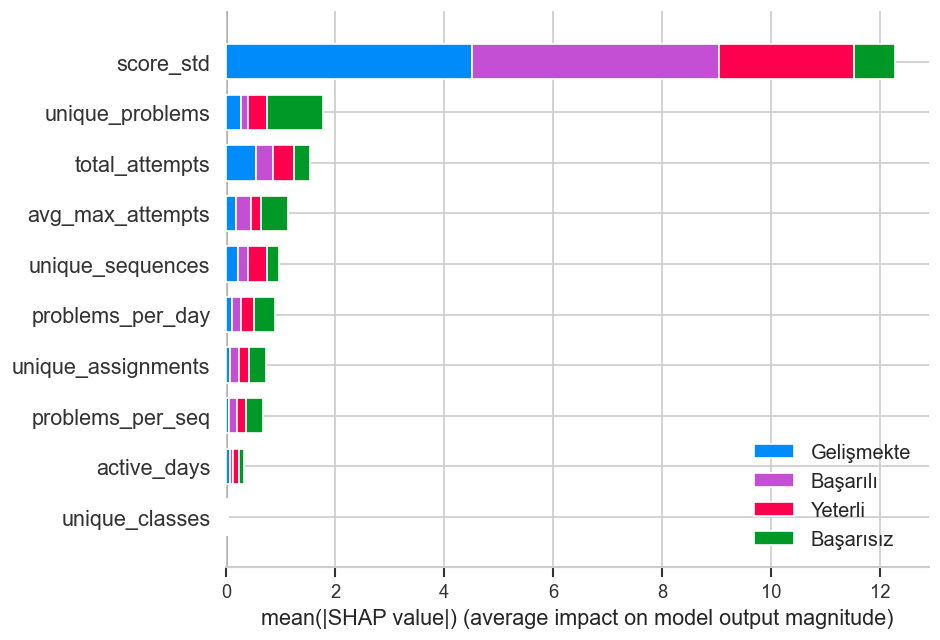

In [22]:
if SHAP_OK and hasattr(FINAL_MODEL, 'feature_importances_'):
    print('SHAP değerleri hesaplanıyor...')
    explainer = shap.TreeExplainer(FINAL_MODEL)
    shap_values = explainer.shap_values(X_test_sc)

    shap.summary_plot(
        shap_values, X_test_sc,
        feature_names=feature_cols,
        class_names=class_names,
        plot_type='bar', show=True
    )
else:
    print('SHAP atlandı.')

---
# BÖLÜM 7 — Stacking Ensemble

XGBoost + Random Forest + LightGBM'i **birinci katman** (base learners) olarak kullan,  
Logistic Regression'ı **meta-model** (ikinci katman) olarak kullan.  
Stacking, base modellerin güçlü yönlerini birleştirir ve tek modelden genellikle 1-3 puan F1 kazanır.

In [23]:
base_estimators = []

if XGBOOST_OK:
    base_estimators.append(('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    )))

base_estimators.append(('rf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)))

if LGBM_OK:
    base_estimators.append(('lgbm', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )))

if len(base_estimators) >= 2:
    meta_model = LogisticRegression(
        max_iter=1000, class_weight='balanced',
        multi_class='multinomial', solver='lbfgs', random_state=RANDOM_STATE
    )

    stacking = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_model,
        cv=5,
        passthrough=False,
        n_jobs=-1
    )

    print('Stacking eğitiliyor...')
    stacking.fit(X_train_sc, y_train_bal)

    y_pred_stack_val  = stacking.predict(X_val_sc)
    y_pred_stack_test = stacking.predict(X_test_sc)

    stack_val_f1  = f1_score(y_val,  y_pred_stack_val,  average='macro')
    stack_test_f1 = f1_score(y_test, y_pred_stack_test, average='macro')
    stack_test_acc = accuracy_score(y_test, y_pred_stack_test)

    print(f'\nStacking Ensemble Sonuçları:')
    print(f'  Val  Macro F1 : {stack_val_f1:.4f}')
    print(f'  Test Macro F1 : {stack_test_f1:.4f}')
    print(f'  Test Accuracy : {stack_test_acc:.4f}')
    print()
    print(classification_report(y_test, y_pred_stack_test, target_names=class_names))

    results['Stacking Ensemble'] = {
        'val_acc'     : accuracy_score(y_val, y_pred_stack_val),
        'val_f1'      : stack_val_f1,
        'test_acc'    : stack_test_acc,
        'test_f1'     : stack_test_f1,
        'model'       : stacking,
        'y_pred_test' : y_pred_stack_test,
        'cv_acc_mean':0, 'cv_acc_std':0, 'cv_f1_mean':0, 'cv_f1_std':0
    }
else:
    print('Stacking için en az 2 model gerekli — atlandı.')

Stacking eğitiliyor...

Stacking Ensemble Sonuçları:
  Val  Macro F1 : 0.7740
  Test Macro F1 : 0.8069
  Test Accuracy : 0.9067

              precision    recall  f1-score   support

   Başarısız       0.50      0.48      0.49        27
  Gelişmekte       0.99      1.00      1.00       124
     Yeterli       0.93      0.92      0.93       123
    Başarılı       0.79      0.85      0.81        26

    accuracy                           0.91       300
   macro avg       0.80      0.81      0.81       300
weighted avg       0.91      0.91      0.91       300



---
# BÖLÜM 8 — Özet Rapor

In [24]:
# Tüm modelleri (tuned + threshold + stacking dahil) karşılaştır
final_compare = pd.DataFrame([
    {
        'Model'       : name,
        'Val Acc'     : r.get('val_acc', 0),
        'Val F1'      : r.get('val_f1',  0),
        'Test Acc'    : r.get('test_acc', 0),
        'Test F1'     : r.get('test_f1',  0),
    }
    for name, r in results.items()
    if r.get('val_f1', 0) > 0 or r.get('test_f1', 0) > 0
]).sort_values('Test F1', ascending=False).reset_index(drop=True)

print('ÖZET RAPOR — EDM 2023 Başarı Sınıflandırması  (v2)')
print(f'Veri Seti')
print(f'   Ham satır sayısı : 1,745,977 (ITS log kaydı)')
print(f'   Aggrege öğrenci  : 1,499')
print(f'   Feature sayısı   : {len(feature_cols)}  (tümü sayısal — encoding gerekmez)')
print()
print(f'Veri Bölme')
print(f'   Eğitim    : %70  ({int(len(y)*0.70)} öğrenci)')
print(f'   Validasyon: %10  ({int(len(y)*0.10)} öğrenci)  ← model seçimi burada')
print(f'   Test      : %20  ({int(len(y)*0.20)} öğrenci)  ← yalnızca final değerlendirme')
print()
print(f'Uygulanan Teknikler')
print(f'   • Data leakage giderildi')
print(f'   • Log1p dönüşümü (çarpık sütunlar)')
print(f'   • SMOTE — sadece eğitim setinde')
print(f'   • StandardScaler — eğitimden fit, diğerlerine transform')
print(f'   • Stratified 5-Fold CV')
print(f'   • Threshold tuning — azınlık sınıfları için')
print(f'   • Stacking Ensemble — XGB + RF + LGBM → LR meta-model')
print()
print('Tüm Model Karşılaştırması (Test F1\'a göre sıralı):')
print(final_compare.to_string(index=False, float_format='{:.4f}'.format))

champion = final_compare.iloc[0]
print(f'En İyi Model : {champion["Model"]}')
print(f'   Test Accuracy  : {champion["Test Acc"]:.4f}')
print(f'   Test Macro F1  : {champion["Test F1"]:.4f}')
print('Modelleme tamamlandı!')

ÖZET RAPOR — EDM 2023 Başarı Sınıflandırması  (v2)
Veri Seti
   Ham satır sayısı : 1,745,977 (ITS log kaydı)
   Aggrege öğrenci  : 1,499
   Feature sayısı   : 10  (tümü sayısal — encoding gerekmez)

Veri Bölme
   Eğitim    : %70  (1049 öğrenci)
   Validasyon: %10  (149 öğrenci)  ← model seçimi burada
   Test      : %20  (299 öğrenci)  ← yalnızca final değerlendirme

Uygulanan Teknikler
   • Data leakage giderildi
   • Log1p dönüşümü (çarpık sütunlar)
   • SMOTE — sadece eğitim setinde
   • StandardScaler — eğitimden fit, diğerlerine transform
   • Stratified 5-Fold CV
   • Threshold tuning — azınlık sınıfları için
   • Stacking Ensemble — XGB + RF + LGBM → LR meta-model

Tüm Model Karşılaştırması (Test F1'a göre sıralı):
                      Model  Val Acc  Val F1  Test Acc  Test F1
                   LightGBM   0.8600  0.7522    0.9167   0.8262
              Random Forest   0.8600  0.7556    0.9067   0.8113
XGBoost (Tuned) + Threshold   0.8733  0.7725    0.9033   0.8093
          Sta